In [304]:
import pandas as pd

try:
    titanic_df = pd.read_csv("/content/drive/MyDrive/train.csv")
except FileNotFoundError as e:
    print(f"Could not load train.csv Error: {e}")
titanic_df
print(titanic_df.head())

titanic_df.info()

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [305]:
import numpy as np

# 1. Calculate the mean of 'age' and fill missing values
age_mean = titanic_df['Age'].mean()
titanic_df['Age'] = titanic_df['Age'].fillna(age_mean)

# 2. Find the mode of 'embarked' and fill missing values
embarked_mode = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)

# 3. Find the mode of 'embark_town' and fill missing values
sex_mode = titanic_df['Sex'].mode()[0]
titanic_df['Sex'] = titanic_df['Sex'].fillna(sex_mode)

titanic_df['Title'] = titanic_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

titanic_df['Title'] = titanic_df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major',
     'Rev','Sir','Jonkheer','Dona'], 'Rare'
)

titanic_df['Title'] = titanic_df['Title'].replace(['Mlle','Ms'], 'Miss')
titanic_df['Title'] = titanic_df['Title'].replace(['Mme'], 'Mrs')

# 4. Drop the 'cabin' column if it exists
if 'Cabin' in titanic_df.columns:
    titanic_df.drop('Cabin', axis=1, inplace=True)

# 5. Verify that all missing values have been handled
print("\nMissing values after handling:")
print(titanic_df.isnull().sum())

titanic_df.info()


Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Title          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Title        891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7

<>:15: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-575918173.py:15: SyntaxWarning: invalid escape sequence '\.'
  titanic_df['Title'] = titanic_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [306]:
print("Encoding categorical features...")

# Convert 'Sex' and 'Embarked' to numerical using one-hot encoding
titanic_df = pd.get_dummies(titanic_df, columns=['Sex','Embarked'], drop_first=True)


titanic_df = pd.get_dummies(titanic_df, columns=['Title'], drop_first=True)

# 'Pclass' is often treated as categorical for better model performance
#titanic_df = pd.get_dummies(titanic_df, columns=['Pclass'], prefix='Pclass')

print("Categorical features encoded. Displaying the first 5 rows with new columns:")
print(titanic_df.head())

print("\nDataFrame information after encoding:")
titanic_df.info()

Encoding categorical features...
Categorical features encoded. Displaying the first 5 rows with new columns:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0      1      0   
2                             Heikkinen, Miss. Laina  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0      1      0   
4                           Allen, Mr. William Henry  35.0      0      0   

             Ticket     Fare  Sex_male  Embarked_Q  Embarked_S  Title_Miss  \
0         A/5 21171   7.2500      True       False        True       False   
1          PC 17599  71.2833     False       False       Fals

In [307]:
from sklearn.model_selection import train_test_split

titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

#titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)

titanic_df['FarePerPerson'] = titanic_df['Fare'] / titanic_df['FamilySize']

print("Defining features (X) and target (y)...")

# Define target variable
y = titanic_df['Survived']

# Define features by dropping the target and irrelevant columns
#X = titanic_df.drop(['Survived', 'Name', 'Ticket', 'PassengerId'], axis=1)

X = titanic_df.drop(['Survived', 'Name', 'Ticket', 'PassengerId', 'SibSp','Parch', 'Fare'], axis=1)


print("Features (X) and Target (y) defined.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

print("\nSplitting data into training and testing sets...")

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
print(X_train.head())

Defining features (X) and target (y)...
Features (X) and Target (y) defined.
Shape of X: (891, 11)
Shape of y: (891,)

Splitting data into training and testing sets...
Data split complete.
Shape of X_train: (712, 11)
Shape of X_test: (179, 11)
Shape of y_train: (712,)
Shape of y_test: (179,)

First 5 rows of X_train:
     Pclass   Age  Sex_male  Embarked_Q  Embarked_S  Title_Miss  Title_Mr  \
331       1  45.5      True       False        True       False      True   
733       2  23.0      True       False        True       False      True   
382       3  32.0      True       False        True       False      True   
704       3  26.0      True       False        True       False      True   
813       3   6.0     False       False        True        True     False   

     Title_Mrs  Title_Rare  FamilySize  FarePerPerson  
331      False       False           1      28.500000  
733      False       False           1      13.000000  
382      False       False           1       7.925

In [308]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate the Decision Tree Classifier
for depth in range(3, 8):
    dtc = DecisionTreeClassifier(
      criterion='entropy',
      max_depth=depth ,
      random_state=42
    )

# Train the model
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [309]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = dtc.predict(X_test)

# Calculate the accuracy score
accuracy_dt = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8547


In [310]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("Initializing and training Random Forest model...")

# Instantiate a Random Forest Classifier model
# n_estimators is the number of trees in the forest
# random_state for reproducibility
random_forest_model = RandomForestClassifier(
    n_estimators=100, random_state=42

    )

# Train the model on the training data
random_forest_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

print("Making predictions on the test set...")
# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

print("Calculating accuracy...")
# Calculate the accuracy of the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")

Initializing and training Random Forest model...
Random Forest model trained successfully.
Making predictions on the test set...
Calculating accuracy...
Random Forest Model Accuracy: 0.8324


In [311]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

print("Initializing and training K-Nearest Neighbors model...")

# Scale numerical features, as KNN is distance-based
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate a K-Nearest Neighbors Classifier model
# Using n_neighbors=5 as a common starting point
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model on the scaled training data
knn_model.fit(X_train_scaled, y_train)
print("K-Nearest Neighbors model trained successfully.")

print("Making predictions on the test set...")
# Make predictions on the scaled test set
y_pred_knn = knn_model.predict(X_test_scaled)

print("Calculating accuracy...")
# Calculate the accuracy of the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"K-Nearest Neighbors Model Accuracy: {accuracy_knn:.4f}")

Initializing and training K-Nearest Neighbors model...
K-Nearest Neighbors model trained successfully.
Making predictions on the test set...
Calculating accuracy...
K-Nearest Neighbors Model Accuracy: 0.8212


In [312]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

print("Initializing and training Support Vector Machine model...")

# Instantiate a Support Vector Classifier model
# Using a linear kernel as a common starting point
# C is the regularization parameter. The strength of the regularization is inversely proportional to C.
# random_state for reproducibility
svm_model = SVC(kernel='linear', random_state=42)

# Train the model on the scaled training data
svm_model.fit(X_train_scaled, y_train)
print("Support Vector Machine model trained successfully.")

print("Making predictions on the test set...")
# Make predictions on the scaled test set
y_pred_svm = svm_model.predict(X_test_scaled)

print("Calculating accuracy...")
# Calculate the accuracy of the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print(f"Support Vector Machine Model Accuracy: {accuracy_svm:.4f}")

Initializing and training Support Vector Machine model...
Support Vector Machine model trained successfully.
Making predictions on the test set...
Calculating accuracy...
Support Vector Machine Model Accuracy: 0.8212


In [313]:
import pandas as pd

# Collect the accuracy scores
model_accuracies = {
    'Decision Tree': accuracy_dt,
    'Random Forest': accuracy_rf,
    'K-Nearest Neighbors': accuracy_knn,
    'Support Vector Machine': accuracy_svm
}

# Create a DataFrame for comparison
accuracy_df = pd.DataFrame(model_accuracies.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Comparative Model Accuracy Table:")
print(accuracy_df.to_markdown(index=False))

Comparative Model Accuracy Table:
| Model                  |   Accuracy |
|:-----------------------|-----------:|
| Decision Tree          |   0.854749 |
| Random Forest          |   0.832402 |
| K-Nearest Neighbors    |   0.821229 |
| Support Vector Machine |   0.821229 |


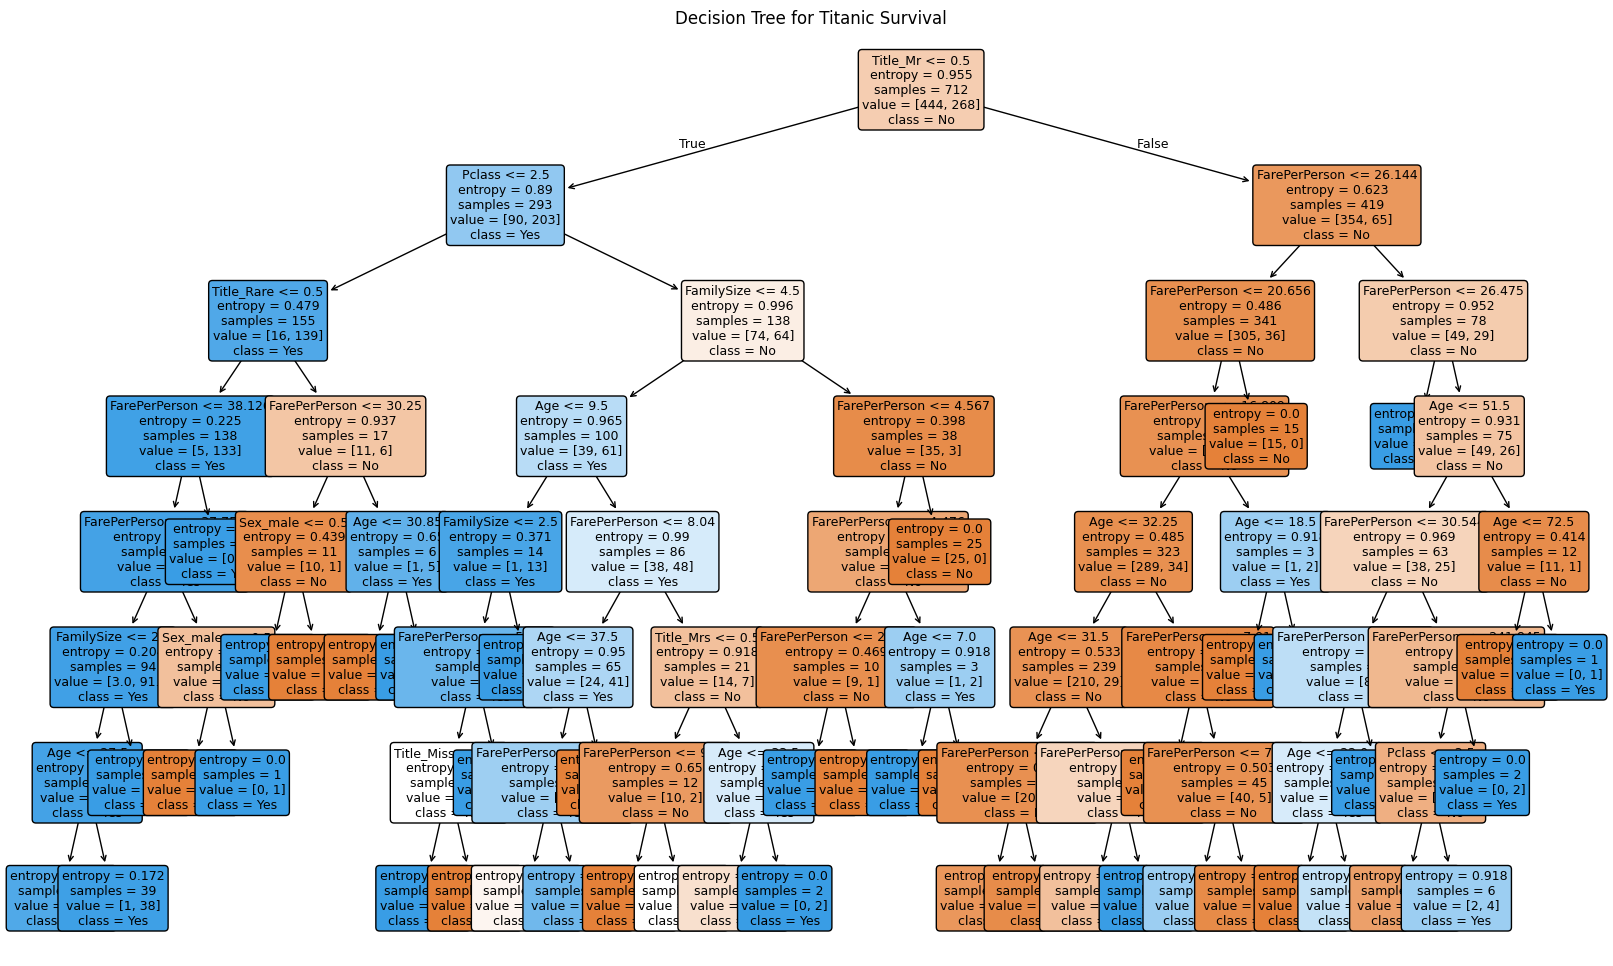

In [314]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))

plot_tree(dtc,
          feature_names=X_train.columns,
          class_names=['No', 'Yes'],
          filled=True,
          rounded=True,
          fontsize=9)

plt.title("Decision Tree on Titanic Data Sheet")
plt.show()
